# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Delaney Tello
- Nombre de alumno 2: Matías Godoy

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/MDS7202-GPT-6/GPT-6)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. La diferencia entre los datos de entrenamiento y los de validación, es que los primeros se usan para que el modelo aprenda los patrones de la información. En cambio, los últimos mencionados se usan principalmente para ajustar hiperparámetros para evitar el sobreajuste, o para evaluar el desempeño del modelo durante el entrenamiento.

2. El mayor desafío es que no se cuenta con etiquetas verdaderas para guiar el aprendizaje, es decir, no hay variable objetivo en la cual el modelo en el entrenamiento se pueda basar para aprender patrones de los datos. Esto dificulta validar la calidad de los grupos o clases formadas y requiere usar otros métodos(como cohesión o separación de clusters).

3. La matriz de confusión es una tabla que se encarga de comparar las predicciones del modelo con las clases reales. Sirve para medir cuántos aciertos y errores se cometieron, y para tener las cantidades según tipo de acierto/error (tp,fp,tn,fn).

4.
  - Accuracy: $\frac{TP+TN}{TP+TN+FP+FN}$. Mide la proporción de predicciones correctas sobre el total.
  - Precision: $\frac{TP}{TP+FP}$. Mide la proporción de predicciones correctas de todas las veces que el modelo predijo “positivo”.
  - Recall: $\frac{TP}{TP+FN}$. Mide la proporción de predicción correcta de positivos reales.
  - F1 score: $2\frac{Precision*Recall}{Precision+Recall}$mide la precision y el recall de forma equilibrada, es un balance de estas dos. Útil en desbalance de clases.

5.
  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  -> Recall: en este caso es más importante detectar la mayor cantidad de fallas posibles (verdaderos positivos). Esto puede implicar falsas alarmas (FP), pero una falla no detectada puede generar altos costos y riesgos en la vida de los mineros, es decir, es mejor tener más FP que FN.
  * Detección de enfermedades altamente contagiosas. -> También recall, por lo explicado anteriormente. En este caso como se trata con enfermedades altamente contagiosas, es mejor prevenir de más antes que lamentar. Por ello se prioriza un modelo con mayor Recall (Mayor cantidad de predicciones correctas a la detección positiva de la enfermedad). Mejor predecir mal que alguien tiene antes a decir que no y que en verdad sí (es menos riegoso).
  * Aprobación de créditos de alto riesgo. -> Precision: En este caso es importante es minimizar los falsos positivos (aprobar a alguien que en realidad no es confiable->implica gastos). Es preferible ser más estricto y aprobar menos.
  * Detección de crímenes.-> F1 score: Finalmente, en este caso un equilibrio entre recall (detectar la mayor cantidad de crímenes) y precision (no acusar erróneamente a inocentes) es lo más sensato, ya que en ambos casos las consecuencias de predecir mal son graves.

  6. La calibración de modelos se refiere a el ajustar las probabilidades que predicen los modelos, para que sean lo más fielmente posible con la realidad, es decir, que sean confiables. Se usa para ayudar en la toma de decisiones de los modelos y en modular los scores. Hace que las probabilidades sean más interpretables y es útil cuando hay que tomar decisiones basadas en la probabilidad.
  


# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv('stats_players.csv')
df.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


In [4]:
df["label"] = df["National_Position"].notna().astype(int)

In [5]:
df[["National_Position","label"]].head(10)

,National_Position,label
0,LS,1
1,RW,1
2,LW,1
3,LS,1
4,GK,1
5,GK,1
6,LS,1
7,RS,1
8,NaN,0
9,GK,1


In [6]:
df = df.drop(columns=["National_Position"])

Borramos la columna 'National_Position' ya que es la que usamos para crear la variable label.

In [7]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

label
0    16513
1     1075
Name: count, dtype: int64
label
0    0.938879
1    0.061121
Name: proportion, dtype: float64


Podemos observar que el dataset está desbalanceado al usar estas clases, ya que la cantidad de la clase 0 representa un 93% de las observaciones, mientras que la clase 1 solo tiene el 6%.

In [8]:
df.columns

Index(['Name', 'Nationality', 'Club_Position', 'Height', 'Weight',
       'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot', 'Skill_Moves',
       'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys', 'label'],
      dtype='object')

In [9]:
numeric_features = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
                    'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing',
                    'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility',
                    'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy',
                    'Penalties', 'Volleys']
categorical_features = [ 'Nationality', 'Club_Position', 'Preffered_Foot',
                        'Work_Rate','Weak_foot','Skill_Moves']
print(f"largo num: {len(numeric_features)}")
print(f"largo cat: {len(categorical_features)}")

largo num: 31
largo cat: 6


La cantidad de cada uno concuerda con el html, en categóricas ahora hay una menos, ya que quitaremos Name.

In [10]:
df[df.isnull().any(axis=1)]

,Name,Nationality,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
383,Didier Drogba,Ivory Coast,NaN,189,80,Right,39,Medium / Low,4,3,...,76,85,85,82,79,78,84,84,76,0


Como existe únicamente un solo jugador con Nulos aparte de National_Position, con el valor nulo en Club_Position, asumiremos que este jugador no pertenece a ningún club ni equipo a nivel nacional, por lo que lo borraremos.

In [11]:
df = df.dropna()
df.drop(columns=["Name"])  # Name es casi único, no aporta

,Nationality,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,Ball_Control,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
0,Portugal,LW,185,80,Right,32,High / Low,4,5,93,...,95,85,92,93,90,81,76,85,88,1
1,Argentina,RW,170,72,Left,29,Medium / Medium,4,4,95,...,68,71,85,95,88,89,90,74,85,1
2,Brazil,LW,174,68,Right,25,High / Medium,5,5,95,...,61,62,78,89,77,79,84,81,83,1
3,Uruguay,ST,182,85,Right,30,High / Medium,4,4,91,...,69,77,87,94,86,86,84,85,88,1
4,Germany,GK,193,92,Right,31,Medium / Medium,4,1,48,...,78,25,25,13,16,14,11,47,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17583,Republic of Ireland,Sub,183,82,Right,19,Medium / Medium,1,1,12,...,56,14,16,13,13,11,13,15,12,0
17584,Republic of Ireland,Sub,185,80,Right,19,Medium / Medium,2,1,13,...,53,12,17,12,11,12,13,16,12,0
17585,England,Res,173,61,Right,18,High / Medium,2,2,44,...,61,41,44,28,42,35,36,42,37,0
17586,Scotland,Sub,180,80,Right,21,Medium / Medium,3,1,17,...,48,15,23,14,12,13,12,24,12,0


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

col_transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


Justificación transformaciones:

- Eliminamos `Name`: identificador casi único (≈100% distinto) ya que no aporta.
- Numéricas se usó StandardScaler: para tener valores con rangos comparables entre ellos.
- Categóricas se usó  OneHotEncoder para que todos los modelos puedan utilizar estas variables.


### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

X = df.drop(columns=["label"])
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6, stratify=y
)

Se usa un test_size=0.2 ya que es un valor típico, y al no ser una cantidad exageradamente grande de datos, no combiene achicar este valor, además se usó stratify para mantener la distribución de clases.

In [14]:

pipeline_xgboost = Pipeline(steps=[
                                    ("preprocessor", col_transformer),
                                    ("classifier", XGBClassifier(
                                        use_label_encoder=False,
                                        eval_metric="logloss",
                                        random_state=6
                                    ))
                                  ])

pipeline_lightgbm = Pipeline(steps=[
                                    ("preprocessor", col_transformer),
                                    ("classifier", LGBMClassifier(
                                        random_state=6
                                    ))
                                    ])


In [15]:

pipeline_xgboost.fit(X_train, y_train)
pipeline_lightgbm.fit(X_train, y_train)

print("Entrenamiento listop")

/Users/matiasgodoy/Universidad/2025-2/Lab MDS/GPT-6/lab5/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:50:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 860, number of negative: 13209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2690
[LightGBM] [Info] Number of data points in the train set: 14069, number of used features: 149
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061127 -> initscore=-2.731721
[LightGBM] [Info] Start training from score -2.731721
Entrenamiento listop


### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report


y_pred_xgb = pipeline_xgboost.predict(X_test)
y_pred_lgbm = pipeline_lightgbm.predict(X_test)


acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
rec_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
print("XGBoost:")
print("Accuracy:", acc_xgb)
print("Precisión (clase positiva):", prec_xgb)
print("Recall (clase positiva):", rec_xgb)
print(classification_report(y_test, y_pred_xgb))

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
prec_lgbm = precision_score(y_test, y_pred_lgbm, pos_label=1)
rec_lgbm = recall_score(y_test, y_pred_lgbm, pos_label=1)
print("LightGBM:")
print("Accuracy:", acc_lgbm)
print("Precisión (clase positiva):", prec_lgbm)
print("Recall (clase positiva):", rec_lgbm)
print(classification_report(y_test, y_pred_lgbm))

XGBoost:
Accuracy: 0.9494030699260944
Precisión (clase positiva): 0.648
Recall (clase positiva): 0.3767441860465116
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3303
           1       0.65      0.38      0.48       215

    accuracy                           0.95      3518
   macro avg       0.80      0.68      0.72      3518
weighted avg       0.94      0.95      0.94      3518

LightGBM:
Accuracy: 0.9499715747583855
Precisión (clase positiva): 0.6666666666666666
Recall (clase positiva): 0.3627906976744186
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3303
           1       0.67      0.36      0.47       215

    accuracy                           0.95      3518
   macro avg       0.81      0.68      0.72      3518
weighted avg       0.94      0.95      0.94      3518



2. Ambos modelos alcanzan un accuracy cercano al 95%, pero este valor está fuertemente influido por el desbalance de clases (muchos más jugadores no seleccionados que seleccionados). Por eso, el accuracy no refleja bien el rendimiento sobre la clase positiva. En esa clase, la precisión es más o menos buena en ambos modelos, lo que significa que cuando el modelo predice un jugador como seleccionado suele acertar. El recall es bajo , lo que indica que se escapan muchos seleccionados reales. En resumen, la cantidad reducida de ejemplos positivos hace que los modelos prioricen predecir la clase mayoritaria, afectando la cobertura de la minoritaria.

3. La métrica más adecuada es el recall de la clase positiva, ya que interesa no dejar fuera jugadores que sí son seleccionados. Como ambos modelos tienen un recall casi idéntico, la diferencia está en la precisión: LightGBM (0.71) supera a XGBoost (0.66). Por lo tanto, LightGBM muestra un mejor desempeño.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

Se siguió el siguiente camino:
- Se tienen más de 50 samples.
- Se está prediciendo una categoría.
- Se tiene labeled data.
- Se tiene menos de 100k samples.
- Se leyó la documentación de Linear SVC como no estamos con la certeza de tener datos linealmente separables, se pasó al siguiente modelo.
- Se revisó KNeighborsClassifier y no hay una distancia para las variables categóricas, a pesar de usar One Hot Encoder.
- Se decide usar SVC con class_weight='balanced' para intentar mitigar el desbalance de clases.

**Respuesta:**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.svm import SVC


ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']


posiciones_validas = ataque + central_ataque + central + central_defensa + defensa + arquero


df_pos = df.copy()


df_pos = df_pos[~df_pos['Club_Position'].isin(['Sub', 'Res'])]


df_pos = df_pos[df_pos['Club_Position'].isin(posiciones_validas)]


def traducir_pos(pos):
    if pos in ataque:
        return 'ataque'
    elif pos in central_ataque:
        return 'central_ataque'
    elif pos in central:
        return 'central'
    elif pos in central_defensa:
        return 'central_defensa'
    elif pos in defensa:
        return 'defensa'
    elif pos in arquero:
        return 'arquero'


df_pos['label'] = df_pos['Club_Position'].apply(traducir_pos)

print("Distribución de clases:")
print(df_pos['label'].value_counts())

X = df_pos.drop(columns=['Club_Position', 'label'])
y = df_pos['label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6, stratify=y
)


num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

col_transformer = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])


pipeline_svc = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", SVC(random_state=7,class_weight="balanced",kernel="rbf")) 
])


pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)


print("Reporte de clasificación con SVC:")
print(classification_report(y_test, y_pred))


Distribución de clases:
label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64
Reporte de clasificación con SVC:
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.77      0.93      0.84        86
        central       0.63      0.44      0.52       182
 central_ataque       0.51      0.51      0.51       116
central_defensa       0.25      0.36      0.29        42
        defensa       0.83      0.89      0.86       236

       accuracy                           0.72       788
      macro avg       0.66      0.69      0.67       788
   weighted avg       0.72      0.72      0.72       788



Como no se indica que realizar con las clases que no están en los grupos, se eliminaron esas filas, asumiendo que estas posiciones no son de interés para el Club.

Se puede ver un desbalance de clases, siendo la de defensa la más representada, y central_defensa la menos representada.

Las clases que tienen muy malos resultados son central_ataque y central_defensa, donde quizás es dificil diferenciarlas entre sí o con un central, la cual es la siguiente con peor rendimiento.

Las demás clases se distinguen bastante bien, siendo la de arquero la que tiene mejor rendimiento, pudiendo reconocer a todos los arqueros correctamente.


## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**  
- `dt` (Decision Tree): Un solo árbol que divide recursivamente el espacio usando la característica y umbral que más reducen la impureza escogida. Es muy interpretable , rápido de entrenar, pero propenso al sobreajuste si no se limita (max_depth, min_samples_split).  
- `rf` (Random Forest): Ensamble de muchos árboles entrenados sobre muestras bootstrap y con selección aleatoria de un subconjunto de features en cada split. Reduce varianza respecto a un árbol único, mejora generalización y es robusto al ruido. Menos interpretable globalmente y muestra importancias de variables.  
- `et` (Extra Trees): Similar a Random Forest pero añade más aleatoriedad. Para cada feature posible genera umbrales aleatorios, lo que disminuye el tiempo de entrenamiento y puede reducir aún más la varianza, pero introduce ligeramente un poco más de sesgo. Es útil cuando se quiere rapidez y robustez con muchas features.  

In [17]:
from pycaret.datasets import get_data
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí

In [18]:
from pycaret.classification import setup, compare_models, evaluate_model

custom_pipe = Pipeline(steps=[('pre', col_transformer)])

clf_exp = setup(
    data=df,
    target="label",
    session_id=6,
    log_experiment=False,
    preprocess= False,
    custom_pipeline=custom_pipe,
    verbose=True
)


models_to_compare = ['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']


best_model = compare_models(include=models_to_compare,sort='Precision')


evaluate_model(best_model)

,Description,Value
0,Session id,6
1,Target,label
2,Target type,Binary
3,Original data shape,"(17587, 39)"
4,Transformed data shape,"(17587, 12388)"
5,Transformed train set shape,"(12310, 12388)"
6,Transformed test set shape,"(5277, 12388)"
7,Numeric features,33
8,Categorical features,5


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9409,0.9167,0.0413,0.8631,0.0776,0.0723,0.1711,0.5990
catboost,CatBoost Classifier,0.9472,0.9367,0.2247,0.7132,0.3398,0.3203,0.3802,3.3530
xgboost,Extreme Gradient Boosting,0.9473,0.9437,0.3285,0.6374,0.4314,0.4067,0.4325,7.2720
lightgbm,Light Gradient Boosting Machine,0.9448,0.9303,0.2235,0.6300,0.3286,0.3070,0.3529,3.2100
dt,Decision Tree Classifier,0.9325,0.6426,0.3124,0.4308,0.3595,0.3251,0.3311,0.3370
et,Extra Trees Classifier,0.9393,0.9319,0.0080,0.4000,0.0156,0.0145,0.0532,1.1320


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

El modelo Random Forest, es aquel que tiene mejor precision, con un valor de 0.86 además tendiendo un muy bajo tiempo de ejecución. 

Podemos ver que en todas las otras métricas también XGBoost es el que tiene mejor rendimiento, pero con un tiempo de ejecución mucho mayor, con 5.45 segundos, en comparación con los 0.5 segundos de Random Forest.

CatBoost iguamente tiene muy buen balance entre todas las métricas y precision, pero igualmente, se demora 4 veces más en ejecutar que Random Forest.

Es por esto, que decidimos quedarnos con Random Forest, ya que a pesar de tener menos accuracy y Recall, tiene una precision mucho mayor, logrando predecir con mucha más certeza cuando dice que un jugador será de la selección nacional, y además tiene un tiempo de ejecución mucho menor.

Luego, pegamos las siguientes imágenes:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
    ![image](img/matrix.png)
    Los verdaderos negativos son muy altos (4949), lo que significa que el modelo identifica casi siempre bien a los jugadores que no deberían ser seleccionados.
    Los verdaderos positivos son extremadamente bajos (solo 6), lo que refleja que el modelo casi nunca identifica correctamente a los jugadores que sí deberían ser seleccionados.


  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
      ![image](img/tresh.png)
    El gráfico muestra que, bajando el threshold a valores alrededor de 0.25, el recall mejora de forma considerable, aunque la precisión disminuya bastante. El umbral por defecto (0.5) no sería el adecuado.

  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
      ![image](img/feat.png)
      	Las variables más importantes son: Reactions, Composure, Ball Control, Standing Tackle, Marking, Heading y Dribbling. Se puede deber  a que son características que realmente marcan la diferencia entre un jugador muy bueno y uno promedio (no se mucho de futbol).

  - **Learning Curve**: ¿El modelo presenta algún problema?
      ![image](img/LC.png)
      
    Se ve una que el training score es de 1, pero el cross validation score es de aprox 0.94, lo que muestra un leve sobreajuste, pero no es mucha diferencia, solo que esa métrica está afectada por el desbalance de clases.


Pd: pido disculpas, pero las fotos no las podía achicar :(

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [28]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np
import time


X_full = df.drop(columns=["label"])
y_full = df["label"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=6
)

def eval_model(m, Xtr, ytr, Xte, yte, name):
    y_pred_tr = m.predict(Xtr)
    y_pred_te = m.predict(Xte)
    metrics = {
        "model": name,
        "train_precision": precision_score(ytr, y_pred_tr, zero_division=0),
        "test_precision": precision_score(yte, y_pred_te, zero_division=0),
        "test_recall": recall_score(yte, y_pred_te, zero_division=0),
        "test_f1": f1_score(yte, y_pred_te, zero_division=0)
    }
    return metrics, classification_report(yte, y_pred_te)



xgb_base = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("classifier", XGBClassifier(
        random_state=6,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        n_jobs=-1
    ))
])
t0 = time.time()
xgb_base.fit(X_train_all, y_train_all)
t1 = time.time()

full_metrics, full_report = eval_model(
    xgb_base, X_train_all, y_train_all, X_test_all, y_test_all, "Completo"
)

print("Tiempo original:", round(t1 - t0, 2), "s")
print(pd.DataFrame([full_metrics]))
print("\nReporte original:\n", full_report)

Tiempo original: 0.69 s
      model  train_precision  test_precision  test_recall   test_f1
0  Completo          0.92381        0.589744     0.213953  0.313993

Reporte original:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      3303
           1       0.59      0.21      0.31       215

    accuracy                           0.94      3518
   macro avg       0.77      0.60      0.64      3518
weighted avg       0.93      0.94      0.93      3518



In [21]:


preproc = xgb_base.named_steps["preprocessor"]
transformed_feature_names = []
for name, trans, cols in preproc.transformers_:
    if name == "num":
        transformed_feature_names.extend(cols)
    elif name == "cat":
        transformed_feature_names.extend(list(trans.get_feature_names_out(cols)))


importances = xgb_base.named_steps["classifier"].feature_importances_
feat_import_df = (pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": importances
})
 .sort_values("importance", ascending=False)
 .reset_index(drop=True)
)

print("Top importancias:")
print(feat_import_df[["feature","importance"]])

Top importancias:
                        feature  importance
0                     Reactions    0.046951
1             Nationality_India    0.030408
2          Nationality_China PR    0.029313
3          Nationality_Bulgaria    0.026155
4             Nationality_Egypt    0.025551
...                         ...         ...
14104        Name_Gennaro Sardo    0.000000
14105  Name_Gennaro Troianiello    0.000000
14106          Name_Genta Miura    0.000000
14107        Name_Geoff Cameron    0.000000
14108            Name_Junya Ito    0.000000

[14109 rows x 2 columns]


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
import time


rank_features = feat_import_df.feature.tolist()
max_k = min(80, len(rank_features))  

if 'X_train_all_tr' not in locals():
    preproc = xgb_base.named_steps['preprocessor']
    X_train_all_tr = preproc.transform(X_train_all)


feature_index_map = {f: i for i, f in enumerate(rank_features)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
rows = []
t0 = time.time()

for k in range(1, max_k + 1):
    current_feats = rank_features[:k]
    idx = [feature_index_map[f] for f in current_feats]
    fold_prec, fold_rec, fold_f1 = [], [], []
    for tr, va in cv.split(X_train_all_tr, y_train_all):
        Xtr_k = X_train_all_tr[tr][:, idx]
        Xva_k = X_train_all_tr[va][:, idx]
        clf = XGBClassifier(
            random_state=6,
            n_estimators=250,
            learning_rate=0.07,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.85,
            eval_metric="logloss",
            n_jobs=-1
        )
        clf.fit(Xtr_k, y_train_all.iloc[tr])
        preds = clf.predict(Xva_k)
        fold_prec.append(precision_score(y_train_all.iloc[va], preds, zero_division=0))
        fold_rec.append(recall_score(y_train_all.iloc[va], preds, zero_division=0))
        fold_f1.append(f1_score(y_train_all.iloc[va], preds, zero_division=0))
    rows.append({
        "k": k,
        "cv_precision": np.mean(fold_prec),
        "cv_recall": np.mean(fold_rec),
        "cv_f1": np.mean(fold_f1),
        "feature_added": current_feats[-1],
        "features_acumuladas": current_feats
    })

perf_multi = pd.DataFrame(rows)
elapsed = time.time() - t0

print(f"Evaluados k=1..{max_k} en {elapsed:.2f}s")
print("\nTop 10 por precisión:")
display(perf_multi.sort_values("cv_precision", ascending=False).head(10))


In [ ]:

best_row = perf_multi.sort_values("cv_precision", ascending=False).iloc[0]


best_k = best_row["k"]
best_features = best_row["features_acumuladas"]

print("Mejor k (por precisión):", best_k)
print("Features seleccionadas:")
print(best_features)

Mejor k (por precisión): 43
Features seleccionadas:
['Reactions', 'Nationality_India', 'Nationality_China PR', 'Nationality_Bulgaria', 'Nationality_Egypt', 'Nationality_Bolivia', 'Composure', 'Nationality_South Africa', 'Nationality_Venezuela', 'Nationality_Peru', 'Nationality_Canada', 'Nationality_Czech Republic', 'Nationality_Hungary', 'Nationality_Slovenia', 'Nationality_Finland', 'Nationality_Ecuador', 'Nationality_Northern Ireland', 'Nationality_Greece', 'Nationality_Wales', 'Nationality_Brazil', 'Nationality_Spain', 'Nationality_Ivory Coast', 'Nationality_Australia', 'Nationality_Paraguay', 'Nationality_Argentina', 'Nationality_Romania', 'Nationality_Republic of Ireland', 'Nationality_England', 'Nationality_Cameroon', 'Nationality_France', 'Nationality_Italy', 'Nationality_Germany', 'Finishing', 'Nationality_Poland', 'Standing_Tackle', 'Stamina', 'Nationality_Scotland', 'Crossing', 'Nationality_Austria', 'Short_Pass', 'Nationality_Chile', 'Work_Rate_High / High', 'Dribbling']


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features
        self.feature_index_map = None

    def fit(self, X, y=None):
        self.feature_index_map = {f: i for i, f in enumerate(transformed_feature_names)}
        self.selected_idx = [self.feature_index_map[f] for f in self.features if f in self.feature_index_map]
        return self

    def transform(self, X):
        return X[:, self.selected_idx]
    

xgb_reduced = Pipeline(steps=[
    ("preprocessor", col_transformer),
    ("selector", FeatureSelector(best_features)),  
    ("classifier", XGBClassifier(
        random_state=6,
        n_estimators=250,
        learning_rate=0.07,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.85,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

best_k = 43

t2 = time.time()
xgb_reduced.fit(X_train_all, y_train_all)
t3 = time.time()

reduced_metrics, reduced_report = eval_model(
    xgb_reduced, X_train_all, y_train_all, X_test_all, y_test_all, f"Reduced_{best_k}"
)

print("Tiempo (reduced):", round(t3 - t2, 2), "s")
print(pd.DataFrame([reduced_metrics]))
print(f"\nReporte REDUCED ({best_k} features):\n", reduced_report)

Tiempo (reduced): 0.29 s
        model  train_precision  test_precision  test_recall   test_f1
0  Reduced_43         0.878924        0.608247     0.274419  0.378205

Reporte REDUCED (43 features):
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      3303
           1       0.61      0.27      0.38       215

    accuracy                           0.94      3518
   macro avg       0.78      0.63      0.67      3518
weighted avg       0.93      0.94      0.93      3518




5.
- Rendimiento: El modelo reducido con 43 obtiene métricas incluso mejores que el modelo con todas las caracteristicas. La precisión se aumenta levemente (de 0.59 a 0.62), el recall mejora (de 0.21 a 0.27) y el F1 también (de 0.31 a 0.38). Ambos mantienen accuracy cercano a 94%. Y lo más importante, es que el tiempo de entrenamiento baja bastante de 0.69 segundos a 0.29.
- Beneficios de reducir variables: simplifica el modelo ya qe al tener menos variables se vuelve menos complejo (menos dimensiones) y con ello, menos propenso a sobreajuste. También se reduce el tiempo de entrenamiento/inferencia ya que hay menos datos que procesar, y mejora la capacidad de generalización al eliminar ruido o redundancia (relacionados con el tema de sobreajuste anteriormente mencionado).  
- Explicabilidad: con menos variables, el modelo es más fácil de interpretar, pues se enfoca en los factores más influyentes. Si hay menos variables, se puede considerar que es más sencillo de explicar para una persona, y hay que considerar que algunas variables no aportan información nueva (son redundantes o ruido) y solo complican la interpretación, por lo que eliminarlas ayuda a la claridad del modelo.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

Brier Score (antes de calibración): 0.0400
Brier Score (después de calibración): 0.0391


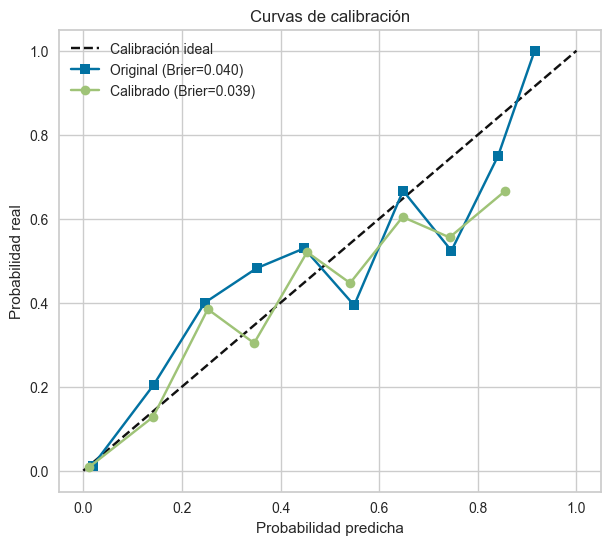

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt


y_proba_base = xgb_reduced.predict_proba(X_test_all)[:, 1]
brier_before = brier_score_loss(y_test_all, y_proba_base)
print(f"Brier Score (antes de calibración): {brier_before:.4f}")

calibrated_clf = CalibratedClassifierCV(
    estimator=xgb_reduced, method="isotonic", cv=5
)
calibrated_clf.fit(X_train_all, y_train_all)


y_proba_cal = calibrated_clf.predict_proba(X_test_all)[:, 1]
brier_after = brier_score_loss(y_test_all, y_proba_cal)
print(f"Brier Score (después de calibración): {brier_after:.4f}")


prob_true_base, prob_pred_base = calibration_curve(y_test_all, y_proba_base, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test_all, y_proba_cal, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Calibración ideal")
plt.plot(prob_pred_base, prob_true_base, "s-", label=f"Original (Brier={brier_before:.3f})")
plt.plot(prob_pred_cal, prob_true_cal, "o-", label=f"Calibrado (Brier={brier_after:.3f})")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad real")
plt.title("Curvas de calibración")
plt.legend()
plt.grid(True)
plt.show()


El análisis de la Brier Score muestra que antes de la calibración el valor era de 0.0400, mientras que después de aplicar la calibración  se redujo a 0.0391. Esta pequeña diferencia indica una leve mejora en la calidad de las probabilidades predichas (porque mientras menor sea el valor de Brier Score, mejor). 

En la curva de calibración se observa que el modelo calibrado se aproxima de un poco mejor manera a la línea diagonal ideal en comparación con el modelo original. Esto significa que las probabilidades estimadas por el modelo después de la calibración se asemejan un poco más con las frecuencias reales observadas en los datos.

En conclusión, la calibración ha permitido ajustar las salidas del modelo, logrando que las probabilidades predichas sean más realistas e interpretables. De esta forma, el modelo no solo clasifica, sino que además entrega estimaciones de probabilidad con más confianza.

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>